# ДЗ 3 - Анализ звука

### Импорты и устройство

In [1]:
from __future__ import annotations

import random
import warnings
import io
from typing import Any

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import Wav2Vec2Model, Wav2Vec2Processor

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 1216
SAMPLE_RATE = 16_000
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## П. 1. Данные: HuggingFace BirdNET

**Текст пункта из условия:** скачать датасет для классификации звука и разделить его на train/test.

In [2]:
# Decode HF audio item (bytes/path/array) to float32 waveform.
def _decode_hf_audio(audio_item: dict[str, Any]) -> np.ndarray:
    if isinstance(audio_item, dict) and audio_item.get("bytes") is not None:
        waveform, sample_rate = sf.read(io.BytesIO(audio_item["bytes"]), dtype="float32")
    elif isinstance(audio_item, dict) and audio_item.get("path"):
        waveform, sample_rate = sf.read(audio_item["path"], dtype="float32")
    elif isinstance(audio_item, dict) and audio_item.get("array") is not None:
        waveform = np.array(audio_item["array"], dtype=np.float32)
        sample_rate = int(audio_item.get("sampling_rate", SAMPLE_RATE))
    else:
        raise ValueError("Unsupported audio format in HF dataset")

    if waveform.ndim > 1:
        waveform = waveform.mean(axis=1)
    waveform = np.array(waveform, dtype=np.float32)

    if sample_rate != SAMPLE_RATE:
        waveform = librosa.resample(waveform, orig_sr=sample_rate, target_sr=SAMPLE_RATE).astype(np.float32)
    return waveform


# Загружает HF BirdNET, декодирует аудио и кодирует метки в целые числа.
def load_hf_birdnet() -> tuple[np.ndarray, list[np.ndarray], list[np.ndarray], np.ndarray, dict[int, str]]:
    from datasets import Audio, load_dataset

    ds = load_dataset("capa2000/binary-classifier-birdnet")
    split = ds["train"].train_test_split(test_size=0.2, seed=RANDOM_STATE)
    train_split = split["train"]
    test_split = split["test"]
    train_split = train_split.cast_column("audio", Audio(decode=False))
    test_split = test_split.cast_column("audio", Audio(decode=False))

    waves_train = [_decode_hf_audio(item["audio"]) for item in train_split]
    waves_test = [_decode_hf_audio(item["audio"]) for item in test_split]

    label_key = "nombreCientifico"
    if label_key not in train_split.column_names:
        raise KeyError(f"Expected label column '{label_key}', available columns: {train_split.column_names}")

    labels_train_raw = [item[label_key] for item in train_split]
    labels_test_raw = [item[label_key] for item in test_split]

    label_to_id = {label: idx for idx, label in enumerate(sorted(set(labels_train_raw + labels_test_raw)))}
    id_to_label = {idx: label for label, idx in label_to_id.items()}
    y_train = np.array([label_to_id[label] for label in labels_train_raw], dtype=np.int64)
    y_test = np.array([label_to_id[label] for label in labels_test_raw], dtype=np.int64)
    return y_train, waves_train, waves_test, y_test, id_to_label


y_train, wav_train, wav_test, y_test, id_to_label = load_hf_birdnet()
print("dataset: HF BirdNET")
print("classes:", np.unique(np.concatenate([y_train, y_test])))
print("label mapping:", id_to_label)


dataset: HF BirdNET
classes: [0 1]
label mapping: {0: 'Accipiter striatus', 1: 'Acropternis orthonyx'}


## П. 2. MFCC и агрегация по времени

**Текст пункта из условия:** извлечь признаки (например, MFCC) и агрегировать последовательность в один вектор.

In [3]:
N_MFCC = 20


# Заменяет NaN/Inf в матрице признаков на средние по столбцам.
def sanitize_features(X: np.ndarray, name: str) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32).copy()
    bad_mask = ~np.isfinite(X)
    bad_count = int(bad_mask.sum())
    if bad_count == 0:
        return X

    X_nan = np.where(np.isfinite(X), X, np.nan)
    with np.errstate(invalid="ignore"):
        column_means = np.nanmean(X_nan, axis=0)
    column_means = np.where(np.isfinite(column_means), column_means, 0.0).astype(np.float32)

    row_idx, col_idx = np.where(bad_mask)
    X[row_idx, col_idx] = column_means[col_idx]
    print(f"[{name}] fixed non-finite values:", bad_count)
    return X


# Преобразует waveform в фиксированный MFCC-вектор (mean + std).
def waveform_to_mfcc_vec(wave: np.ndarray, sr: int) -> np.ndarray:
    wave = np.asarray(wave, dtype=np.float32).reshape(-1)
    if wave.size == 0:
        return np.zeros(2 * N_MFCC, dtype=np.float32)
    mfcc = librosa.feature.mfcc(y=wave, sr=sr, n_mfcc=N_MFCC)
    mfcc = np.nan_to_num(mfcc, nan=0.0, posinf=0.0, neginf=0.0)
    m = mfcc.mean(axis=1)
    s = mfcc.std(axis=1)
    return np.concatenate([m, s]).astype(np.float32)


X_mfcc_train = np.stack([waveform_to_mfcc_vec(w, SAMPLE_RATE) for w in tqdm(wav_train, desc="MFCC train")])
X_mfcc_test = np.stack([waveform_to_mfcc_vec(w, SAMPLE_RATE) for w in tqdm(wav_test, desc="MFCC test")])
X_mfcc_train = sanitize_features(X_mfcc_train, "MFCC train")
X_mfcc_test = sanitize_features(X_mfcc_test, "MFCC test")
print("MFCC shape:", X_mfcc_train.shape)


MFCC train:   0%|          | 0/256 [00:00<?, ?it/s]

MFCC test:   0%|          | 0/64 [00:00<?, ?it/s]

MFCC shape: (256, 40)


## П. 3. Визуализация MFCC-пространства (PCA + t-SNE)

**Текст пункта из условия:** визуализировать объекты в признаковом пространстве с понижением размерности и цветами классов.

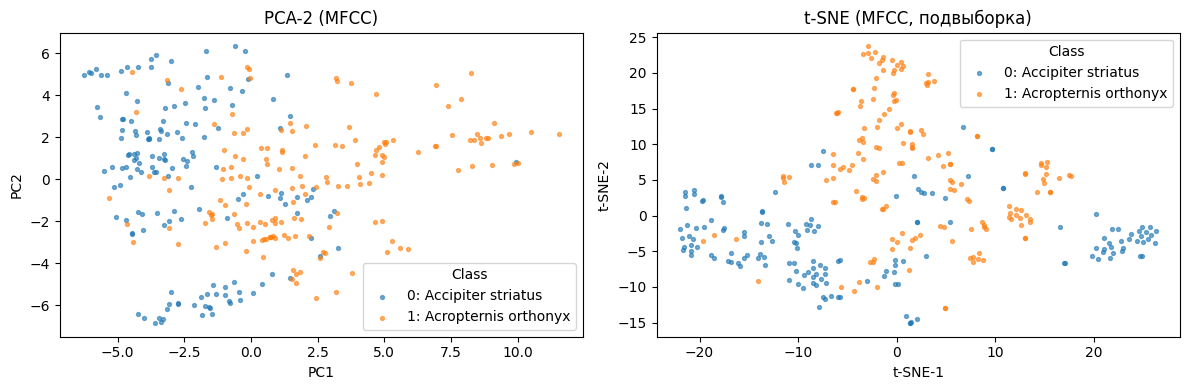

In [4]:
sc_mfcc = StandardScaler()
Z_mfcc = sc_mfcc.fit_transform(np.vstack([X_mfcc_train, X_mfcc_test]))
y_all = np.concatenate([y_train, y_test])

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca = pca2.fit_transform(Z_mfcc)

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto")
Z_tsne = tsne.fit_transform(Z_mfcc[: min(2000, len(Z_mfcc))])
y_tsne = y_all[: len(Z_tsne)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c in np.unique(y_all):
    m = y_all == c
    ax[0].scatter(Z_pca[m, 0], Z_pca[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[0].set_title("PCA-2 (MFCC)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].legend(title="Class")
for c in np.unique(y_tsne):
    m = y_tsne == c
    ax[1].scatter(Z_tsne[m, 0], Z_tsne[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[1].set_title("t-SNE (MFCC, подвыборка)")
ax[1].set_xlabel("t-SNE-1")
ax[1].set_ylabel("t-SNE-2")
ax[1].legend(title="Class")
plt.tight_layout()
plt.show()


## П. 4. Три классические модели на MFCC

**Текст пункта из условия:** выбрать метрику качества и оценить не менее трех классических ML-моделей.

In [5]:
# Обучает sklearn-модель и возвращает метрики качества.
def eval_sklearn(name: str, model: Any, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray) -> dict[str, Any]:
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(name, "acc=", round(acc, 4), "macro-F1=", round(f1, 4))
    return {"name": name, "acc": acc, "f1": f1, "pipe": pipe}


models_mfcc = [
    eval_sklearn("LR", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_mfcc_train, y_train, X_mfcc_test, y_test),
    eval_sklearn("RF", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X_mfcc_train, y_train, X_mfcc_test, y_test),
    eval_sklearn("SVM", SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE), X_mfcc_train, y_train, X_mfcc_test, y_test),
]


LR acc= 0.9375 macro-F1= 0.9369
RF acc= 0.9531 macro-F1= 0.9526
SVM acc= 0.9688 macro-F1= 0.9686


## П. 5. Предобученный Wav2Vec2 (сырой сигнал, 16 kHz)

**Текст пункта из условия:** взять предобученную DL-модель извлечения признаков и повторить пункты 3-4 для ее признаков.

In [6]:
W2V_NAME = "facebook/wav2vec2-base-960h"
processor = Wav2Vec2Processor.from_pretrained(W2V_NAME)
w2v = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device)
w2v.eval()


# Усредняет скрытые состояния Wav2Vec2 по времени с учетом attention mask.
def _mean_pool_w2v_last_hidden(
    backbone: Wav2Vec2Model, last_hidden: torch.Tensor, attention_mask: torch.Tensor | None
) -> torch.Tensor:
    """Processor mask is on raw samples; last_hidden is on feature frames."""
    if attention_mask is None:
        return last_hidden.mean(dim=1)
    subs = backbone._get_feature_vector_attention_mask(last_hidden.shape[1], attention_mask)
    m = subs.unsqueeze(-1).to(dtype=last_hidden.dtype)
    return (last_hidden * m).sum(dim=1) / m.sum(dim=1).clamp(min=1e-6)


# Извлекает frozen-эмбеддинги Wav2Vec2 для списка waveform-ов.
def extract_w2v_vectors(waves: list[np.ndarray], batch_size: int) -> np.ndarray:
    out = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(waves), batch_size), desc="W2V encode"):
            batch = waves[i : i + batch_size]
            inputs = processor(batch, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True, return_attention_mask=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            hidden = w2v(**inputs).last_hidden_state
            am = inputs.get("attention_mask")
            pooled = _mean_pool_w2v_last_hidden(w2v, hidden, am)
            out.append(pooled.cpu().numpy())
    return np.vstack(out).astype(np.float32)


X_w2v_train = extract_w2v_vectors(wav_train, batch_size=8)
X_w2v_test = extract_w2v_vectors(wav_test, batch_size=8)
X_w2v_train = sanitize_features(X_w2v_train, "W2V frozen train")
X_w2v_test = sanitize_features(X_w2v_test, "W2V frozen test")
print("W2V feats:", X_w2v_train.shape)


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


W2V encode:   0%|          | 0/32 [00:00<?, ?it/s]

W2V encode:   0%|          | 0/8 [00:00<?, ?it/s]

W2V feats: (256, 768)


### Повтор п. 3-4 для замороженного Wav2Vec2

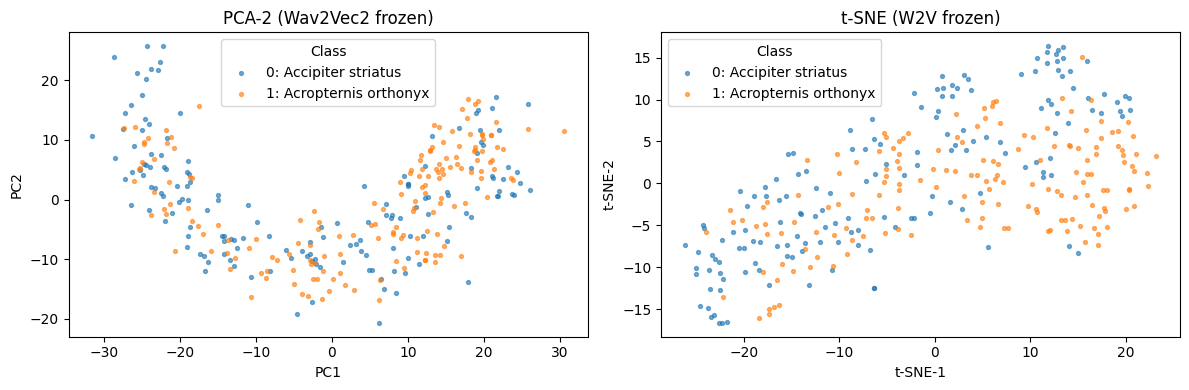

LR+w2v acc= 0.8438 macro-F1= 0.8424
RF+w2v acc= 0.8281 macro-F1= 0.8271
SVM+w2v acc= 0.8594 macro-F1= 0.8565


In [7]:
sc_w = StandardScaler()
Z_w = sc_w.fit_transform(np.vstack([X_w2v_train, X_w2v_test]))
pca_w = PCA(n_components=2, random_state=RANDOM_STATE)
Z_w_pca = pca_w.fit_transform(Z_w)
sub = min(2000, len(Z_w))
tsne_w = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto")
Z_w_tsne = tsne_w.fit_transform(Z_w[:sub])
y_w_tsne = y_all[:sub]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c in np.unique(y_all):
    m = y_all == c
    ax[0].scatter(Z_w_pca[m, 0], Z_w_pca[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[0].set_title("PCA-2 (Wav2Vec2 frozen)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].legend(title="Class")
for c in np.unique(y_w_tsne):
    m = y_w_tsne == c
    ax[1].scatter(Z_w_tsne[m, 0], Z_w_tsne[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[1].set_title("t-SNE (W2V frozen)")
ax[1].set_xlabel("t-SNE-1")
ax[1].set_ylabel("t-SNE-2")
ax[1].legend(title="Class")
plt.tight_layout()
plt.show()

models_w2v = [
    eval_sklearn("LR+w2v", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_w2v_train, y_train, X_w2v_test, y_test),
    eval_sklearn("RF+w2v", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X_w2v_train, y_train, X_w2v_test, y_test),
    eval_sklearn("SVM+w2v", SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE), X_w2v_train, y_train, X_w2v_test, y_test),
]


## П. 6. Классификационная голова на замороженном Wav2Vec2

**Текст пункта из условия:** обучить классификационную голову поверх модели извлечения признаков и оценить качество.

In [8]:
NUM_CLASSES = int(np.max(y_train)) + 1
HIDDEN = w2v.config.hidden_size


# Классификатор: Wav2Vec2-backbone + линейная голова классификации.
class W2VClassifier(nn.Module):
    def __init__(self, backbone: Wav2Vec2Model, n_classes: int) -> None:
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(HIDDEN, n_classes)

    def forward(self, input_values: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        out = self.backbone(input_values, attention_mask=attention_mask)
        h = out.last_hidden_state
        pooled = _mean_pool_w2v_last_hidden(self.backbone, h, attention_mask)
        return self.head(pooled)


# Переключает trainable-состояние для всех параметров модуля.
def set_module_trainable(module: nn.Module, trainable: bool) -> None:
    for param in module.parameters():
        param.requires_grad = trainable


# Формирует батч для Wav2Vec2 с padding и attention mask.
def collate_fn(batch: list[tuple[np.ndarray, int]]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    waves, labels = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.long)
    inputs = processor(list(waves), sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True, return_attention_mask=True)
    return inputs.input_values, inputs.attention_mask, labels


# Датасет-обертка для waveform-ов и числовых меток.
class WaveDataset(Dataset):
    def __init__(self, waves: list[np.ndarray], labels: np.ndarray) -> None:
        self.waves = waves
        self.labels = labels

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[np.ndarray, int]:
        return self.waves[idx], int(self.labels[idx])


train_ds = WaveDataset(wav_train, y_train)
test_ds = WaveDataset(wav_test, y_test)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)

model_head = W2VClassifier(w2v, NUM_CLASSES).to(device)
set_module_trainable(model_head.backbone, False)
set_module_trainable(model_head.head, True)

opt = torch.optim.AdamW(model_head.head.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()


# Выполняет одну эпоху head-only обучения/оценки.
def run_epoch(model: nn.Module, loader: DataLoader, train: bool) -> float:
    model.train(train)
    total, correct = 0, 0
    for x, mask, y in loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        if train:
            opt.zero_grad()
        logits = model(x, mask)
        loss = crit(logits, y)
        if train:
            loss.backward()
            opt.step()
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


### Продолжение п.6: цикл обучения и метрики


In [9]:
for epoch in range(3):
    acc_train = run_epoch(model_head, train_loader, True)
    acc_test = run_epoch(model_head, test_loader, False)
    print(f"epoch {epoch+1} train_acc={acc_train:.4f} test_acc={acc_test:.4f}")

head_only_test_acc = acc_test
print("Head-only test acc:", head_only_test_acc)


epoch 1 train_acc=0.5117 test_acc=0.5781
epoch 2 train_acc=0.6211 test_acc=0.5938
epoch 3 train_acc=0.6367 test_acc=0.6562
Head-only test acc: 0.65625


## П. 7. Разморозка backbone и дообучение

**Текст пункта из условия:** разморозить экстрактор признаков, дообучить вместе с головой и повторить пункты 3-4 для дообученных признаков.

In [10]:
set_module_trainable(model_head.backbone, True)
opt_ft = torch.optim.AdamW(model_head.parameters(), lr=3e-5, weight_decay=0.01)


# Выполняет одну эпоху полного fine-tune обучения/оценки.
def run_epoch_ft(model: nn.Module, loader: DataLoader, train: bool) -> float:
    model.train(train)
    total, correct = 0, 0
    for x, mask, y in loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        if train:
            opt_ft.zero_grad()
        logits = model(x, mask)
        loss = crit(logits, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_ft.step()
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


for epoch in range(2):
    acc_train = run_epoch_ft(model_head, train_loader, True)
    acc_test = run_epoch_ft(model_head, test_loader, False)
    print(f"finetune ep {epoch+1} train_acc={acc_train:.4f} test_acc={acc_test:.4f}")

finetuned_test_acc = acc_test
print("Finetuned test acc:", finetuned_test_acc)


finetune ep 1 train_acc=0.7891 test_acc=0.9062
finetune ep 2 train_acc=0.8828 test_acc=0.9375
Finetuned test acc: 0.9375


### Продолжение п.7: признаки после fine-tune


In [11]:
w2v_ft = model_head.backbone
w2v_ft.eval()


# Извлекает эмбеддинги после дообучения backbone.
def extract_w2v_ft(waves: list[np.ndarray], batch_size: int) -> np.ndarray:
    out = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(waves), batch_size), desc="W2V finetuned encode"):
            batch = waves[i : i + batch_size]
            inputs = processor(batch, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True, return_attention_mask=True)
            iv, mask = inputs.input_values.to(device), inputs.attention_mask.to(device)
            hidden = w2v_ft(iv, attention_mask=mask).last_hidden_state
            pooled = _mean_pool_w2v_last_hidden(w2v_ft, hidden, mask)
            out.append(pooled.cpu().numpy())
    return np.vstack(out).astype(np.float32)


X_ft_train = extract_w2v_ft(wav_train, batch_size=8)
X_ft_test = extract_w2v_ft(wav_test, batch_size=8)
X_ft_train = sanitize_features(X_ft_train, "W2V finetuned train")
X_ft_test = sanitize_features(X_ft_test, "W2V finetuned test")


W2V finetuned encode:   0%|          | 0/32 [00:00<?, ?it/s]

W2V finetuned encode:   0%|          | 0/8 [00:00<?, ?it/s]

### Продолжение п.7: визуализация и модели после fine-tune

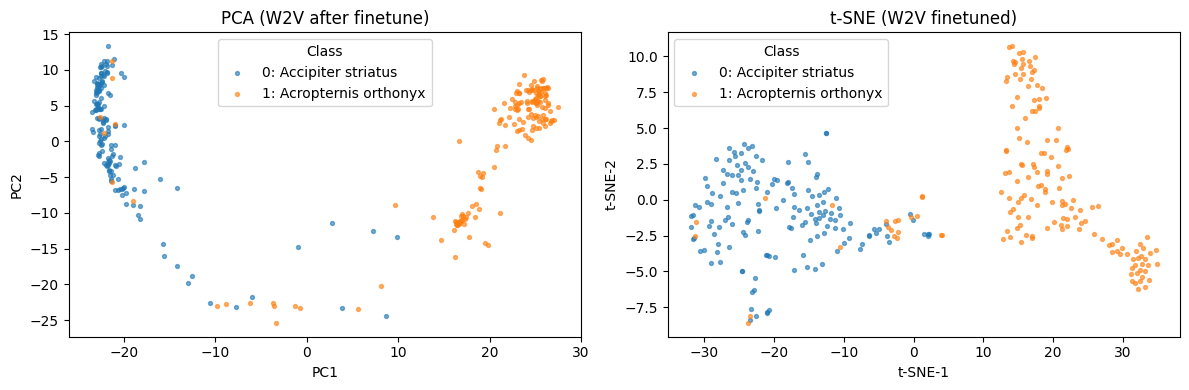

In [12]:
sc_ft = StandardScaler()
Z_ft = sc_ft.fit_transform(np.vstack([X_ft_train, X_ft_test]))
pca_ft = PCA(n_components=2, random_state=RANDOM_STATE)
Z_ft_pca = pca_ft.fit_transform(Z_ft)
sub2 = min(2000, len(Z_ft))
tsne_ft = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto")
Z_ft_tsne = tsne_ft.fit_transform(Z_ft[:sub2])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c in np.unique(y_all):
    m = y_all == c
    ax[0].scatter(Z_ft_pca[m, 0], Z_ft_pca[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[0].set_title("PCA (W2V after finetune)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].legend(title="Class")
y_ft_tsne = y_all[:sub2]
for c in np.unique(y_ft_tsne):
    m = y_ft_tsne == c
    ax[1].scatter(Z_ft_tsne[m, 0], Z_ft_tsne[m, 1], s=8, alpha=0.6, label=f"{c}: {id_to_label.get(int(c), c)}")
ax[1].set_title("t-SNE (W2V finetuned)")
ax[1].set_xlabel("t-SNE-1")
ax[1].set_ylabel("t-SNE-2")
ax[1].legend(title="Class")
plt.tight_layout()
plt.show()


In [13]:
models_ft = [
    eval_sklearn("LR+ft", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_ft_train, y_train, X_ft_test, y_test),
    eval_sklearn("RF+ft", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X_ft_train, y_train, X_ft_test, y_test),
    eval_sklearn("SVM+ft", SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE), X_ft_train, y_train, X_ft_test, y_test),
]


LR+ft acc= 0.9062 macro-F1= 0.9062
RF+ft acc= 0.9531 macro-F1= 0.9528
SVM+ft acc= 0.9531 macro-F1= 0.9528


## П. 8. Лучшее признаковое пространство и пары объектов

**Текст пункта из условия:** выбрать лучшее признаковое пространство, найти две самые близкие и две самые далекие аудиозаписи и показать их спектрограммы.

In [18]:
rows = []
for m in models_mfcc:
    rows.append({"space": "MFCC", "model": m["name"], "acc": m["acc"]})
for m in models_w2v:
    rows.append({"space": "W2V_frozen", "model": m["name"], "acc": m["acc"]})
for m in models_ft:
    rows.append({"space": "W2V_finetuned", "model": m["name"], "acc": m["acc"]})
rows.append({"space": "NN_head", "model": "linear_on_frozen_w2v", "acc": head_only_test_acc})
rows.append({"space": "NN_finetune", "model": "full", "acc": finetuned_test_acc})
df = pd.DataFrame(rows).sort_values("acc", ascending=False)
display(df)

best_row = df.iloc[0]
print("Best by test acc:", best_row.to_dict())

best_space_name = best_row["space"]
if best_space_name == "MFCC":
    X_space = np.vstack([X_mfcc_train, X_mfcc_test])
elif best_space_name == "W2V_frozen":
    X_space = np.vstack([X_w2v_train, X_w2v_test])
elif best_space_name == "W2V_finetuned":
    X_space = np.vstack([X_ft_train, X_ft_test])
elif best_space_name == "NN_head":
    X_space = np.vstack([X_w2v_train, X_w2v_test])
elif best_space_name == "NN_finetune":
    X_space = np.vstack([X_ft_train, X_ft_test])
else:
    X_space = np.vstack([X_ft_train, X_ft_test])

sc_b = StandardScaler()
Xn = sc_b.fit_transform(X_space)


,space,model,acc
2,MFCC,SVM,0.968750
1,MFCC,RF,0.953125
7,W2V_finetuned,RF+ft,0.953125
8,W2V_finetuned,SVM+ft,0.953125
0,MFCC,LR,0.937500
10,NN_finetune,full,0.937500
6,W2V_finetuned,LR+ft,0.906250
5,W2V_frozen,SVM+w2v,0.859375
3,W2V_frozen,LR+w2v,0.843750
4,W2V_frozen,RF+w2v,0.828125


Best by test acc: {'space': 'MFCC', 'model': 'SVM', 'acc': 0.96875}


In [15]:
# Находит ближайшую и самую дальнюю пару объектов в пространстве признаков.
def closest_farthest_pair(X: np.ndarray, max_n: int) -> tuple[tuple[int, int], tuple[int, int], np.ndarray, tuple[int, int]]:
    n = min(len(X), max_n)
    Xs = X[:n]
    D = pairwise_distances(Xs, metric="euclidean")
    np.fill_diagonal(D, np.inf)
    k = int(np.argmin(D))
    i, j = divmod(k, D.shape[1])
    min_pair = (i, j)
    min_d = float(np.linalg.norm(Xs[i] - Xs[j]))
    D2 = pairwise_distances(Xs, metric="euclidean")
    np.fill_diagonal(D2, -np.inf)
    k2 = int(np.argmax(D2))
    p, q = divmod(k2, D2.shape[1])
    max_pair = (p, q)
    max_d = float(np.linalg.norm(Xs[p] - Xs[q]))
    return min_pair, max_pair, min_d, max_d


min_pair, max_pair, min_d, max_d = closest_farthest_pair(Xn, max_n=1000)
print("closest pair idx:", min_pair, "dist", min_d)
print("farthest pair idx:", max_pair, "dist", max_d)


closest pair idx: (237, 269) dist 0.14910806715488434
farthest pair idx: (23, 87) dist 20.014606475830078


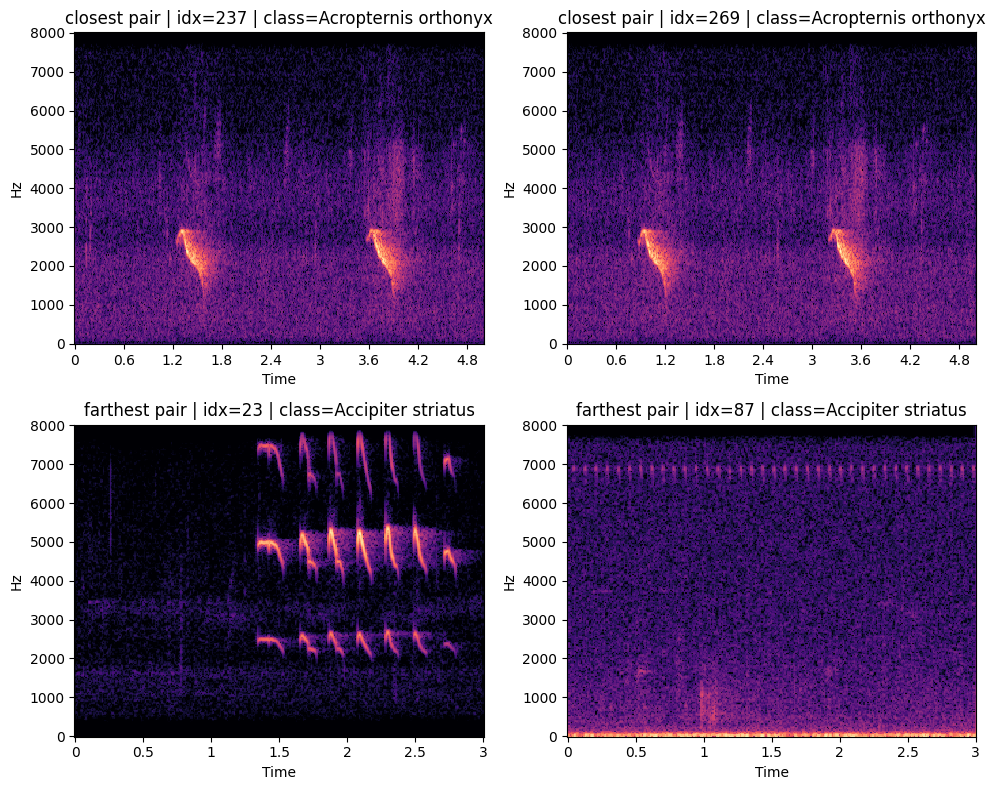

In [16]:
wav_all = wav_train + wav_test
pairs = [min_pair, max_pair]
titles = ["closest pair", "farthest pair"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for r, (a, b) in enumerate(pairs):
    for c, idx in enumerate([a, b]):
        ax = axes[r, c]
        y_w = wav_all[idx]
        S = np.abs(librosa.stft(y_w, n_fft=512, hop_length=160))
        S_db = librosa.amplitude_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=SAMPLE_RATE, x_axis="time", y_axis="hz", ax=ax, hop_length=160)
        cls = int(y_all[idx]) if idx < len(y_all) else -1
        cls_name = id_to_label.get(cls, str(cls))
        ax.set_title(f"{titles[r]} | idx={idx} | class={cls_name}")
plt.tight_layout()
plt.show()
